<h1> SVM (Support Vector Machine)

For this step, we will build a simple Linear SVM from scratch, comprising:
- Hinge Loss
- Gradient Descent
- L2 Regularization
- Prediction
- Decision Function

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

from src.svm import SVM

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.svm import SVC


<h3> Step 1: Internal Test and Custom SVM Evaluation

In [2]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

In [3]:
model = SVM(
    learning_rate=0.001,
    n_iterations=1000,
    lambda_param=0.01
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

model.fit(
    X_scaled,
    y
)

print("model.w: \n", model.w)
print("\nmodel.b: \n", model.b)

model.w: 
 [-1.01347014  2.29647827]

model.b: 
 0.6879999999999405


In [4]:
scores = model.decision_function(
    X_scaled
)

print(
    scores[:20]
)

[-0.96022743 -1.3998817   3.20345417 -1.19045987 -1.17837817 -0.94356084
 -1.09203414  2.17641245 -0.78705198  2.64614182 -1.06107103 -0.92298485
  2.50672373  2.90144842  3.11113779 -1.15347175 -0.88617306  2.2376517
  2.25254242  2.60204426]


In other words, it has constructed a hyperplane model:

$9.516x_1 + 10.063x_2 - 34.201 = 0$

The weight vector:
w = [w1, w2]

determines the orientation of the decision boundary.

If:

$f(x)>0$

then:
class = 1

And if:

$f(x)<0$

then:
class = 0

In [5]:
predictions = model.predict(
    X_scaled
)

print(
    predictions[:20]
)

[0 0 1 0 0 0 0 1 0 1 0 0 1 1 1 0 0 1 1 1]


In [6]:
accuracy = accuracy_score(
    y,
    predictions
)

print("accuracy: ", accuracy)

accuracy:  1.0


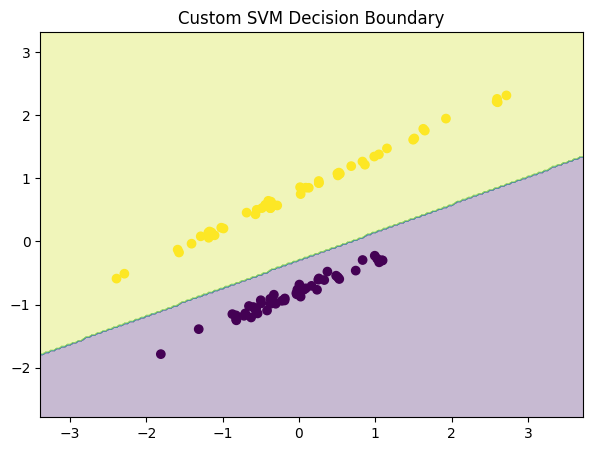

In [7]:
x_min, x_max = X_scaled[:,0].min()-1, X_scaled[:,0].max()+1
y_min, y_max = X_scaled[:,1].min()-1, X_scaled[:,1].max()+1


xx, yy = np.meshgrid(
    np.linspace(
        x_min,
        x_max,
        200
    ),
    np.linspace(
        y_min,
        y_max,
        200
    )
)


grid = np.c_[
    xx.ravel(),
    yy.ravel()
]


decision_values = model.decision_function(
    grid
)


decision_values = decision_values.reshape(
    xx.shape
)


plt.figure(
    figsize=(7,5)
)


plt.contourf(
    xx,
    yy,
    decision_values > 0,
    alpha=0.3
)


plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=y
)


plt.title(
    "Custom SVM Decision Boundary"
)


plt.show()

<h3> Step 2: Custom SVM vs Scikit-Learn SVM

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [10]:
custom_svm = SVM(
    learning_rate=0.001,
    n_iterations=1000,
    lambda_param=0.01
)

custom_svm.fit(
    X_train_scaled,
    y_train
)

custom_pred = custom_svm.predict(
    X_test_scaled
)

In [11]:
sklearn_svm = SVC(
    kernel="linear",
    C=1
)

sklearn_svm.fit(
    X_train_scaled,
    y_train
)

SVC(C=1, kernel='linear')

In [12]:
sklearn_pred = sklearn_svm.predict(
    X_test_scaled
)

In [13]:
custom_accuracy = accuracy_score(
    y_test,
    custom_pred
)

sklearn_accuracy = accuracy_score(
    y_test,
    sklearn_pred
)

print(
    "Custom SVM:",
    custom_accuracy
)

print(
    "Sklearn SVM:",
    sklearn_accuracy
)

Custom SVM: 1.0
Sklearn SVM: 1.0


In [14]:
print(
    custom_svm.w,
    custom_svm.b
)

[-1.80358138  3.25224349] -1.1789999999998866


In [15]:
print(
    sklearn_svm.coef_,
    sklearn_svm.intercept_
)

[[-0.85164877  1.5302243 ]] [0.03552691]


In [16]:
custom_svm.get_support_vectors(
    X_train_scaled,
    y_train
)

array([[-1.38980359, -0.10828792],
       [-1.54811104, -0.24130274],
       [ 0.80060581,  1.08530203],
       [-0.30733165,  0.46962103],
       [-1.56517121, -0.19844398],
       [-0.3943123 ,  0.4289001 ],
       [-0.34833568,  0.47323857],
       [ 0.45871314,  0.92351191],
       [-1.09909324,  0.01840143],
       [-1.17322849, -0.01899653],
       [-0.39185435,  0.42980045],
       [-0.01142689,  0.64134873],
       [-2.33789042, -0.63583684],
       [ 2.47814482,  2.0298232 ]])

In [17]:
sklearn_svm.support_vectors_

array([[-1.29932437, -1.40003544],
       [-0.51522711, -0.96310902],
       [-1.54811104, -0.24130274],
       [-1.09909324,  0.01840143]])

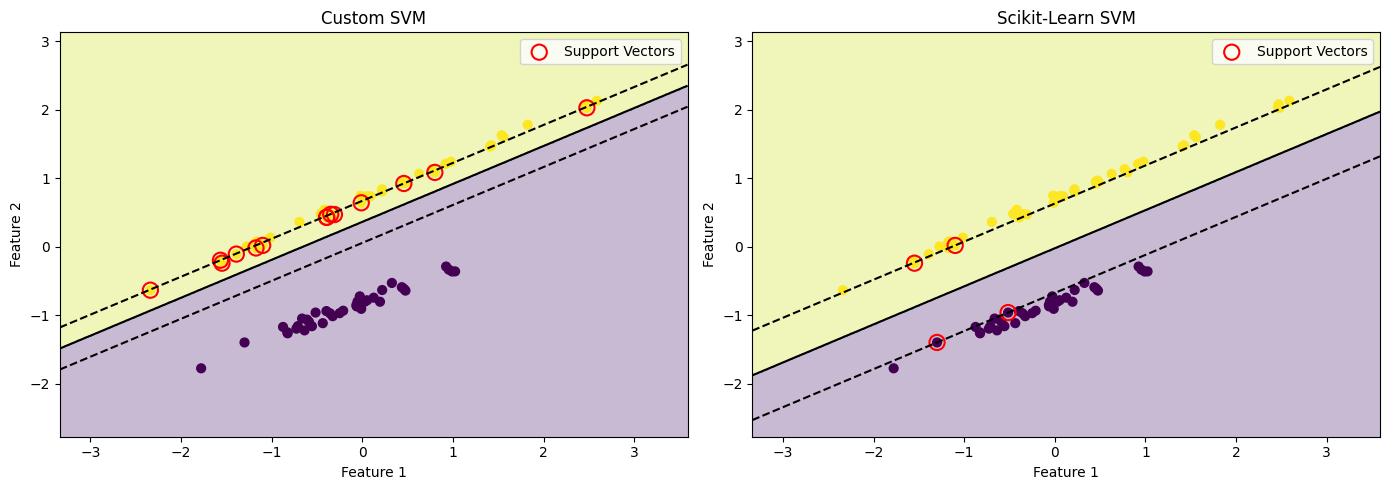

In [18]:
# Grid for visualization
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]


# Decision function values
custom_decision = custom_svm.decision_function(grid_points).reshape(xx.shape)
sklearn_decision = sklearn_svm.decision_function(grid_points).reshape(xx.shape)


# Support vectors
custom_support_vectors = custom_svm.get_support_vectors(
    X_train_scaled,
    y_train
)

sklearn_support_vectors = sklearn_svm.support_vectors_


# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- Custom SVM ----------------
axes[0].contourf(
    xx,
    yy,
    custom_decision > 0,
    alpha=0.3
)

axes[0].contour(
    xx,
    yy,
    custom_decision,
    levels=[-1, 0, 1],
    colors="black",
    linestyles=["--", "-", "--"]
)

axes[0].scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    s=40
)

axes[0].scatter(
    custom_support_vectors[:, 0],
    custom_support_vectors[:, 1],
    s=120,
    facecolors="none",
    edgecolors="red",
    linewidths=1.5,
    label="Support Vectors"
)

axes[0].set_title("Custom SVM")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].legend()


# ---------------- Sklearn SVM ----------------
axes[1].contourf(
    xx,
    yy,
    sklearn_decision > 0,
    alpha=0.3
)

axes[1].contour(
    xx,
    yy,
    sklearn_decision,
    levels=[-1, 0, 1],
    colors="black",
    linestyles=["--", "-", "--"]
)

axes[1].scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    s=40
)

axes[1].scatter(
    sklearn_support_vectors[:, 0],
    sklearn_support_vectors[:, 1],
    s=120,
    facecolors="none",
    edgecolors="red",
    linewidths=1.5,
    label="Support Vectors"
)

axes[1].set_title("Scikit-Learn SVM")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()

plt.tight_layout()
plt.show()

### Linear SVM From Scratch - Summary

In this notebook, a Linear SVM was implemented from scratch using:

- Hinge Loss
- Gradient Descent
- L2 Regularization
- Decision Function
- Binary Classification


The custom implementation was compared with Scikit-Learn SVM.

#### Results

- Both models achieved the same classification accuracy.
- Decision boundaries were very similar.
- The custom model successfully reproduced the main behavior of Linear SVM.

#### Differences

The parameter values and number of support vectors were different because:

- Scikit-Learn uses an optimized SVM solver.
- The custom model uses gradient descent approximation.

#### Conclusion

This implementation demonstrates the core ideas of SVM:

- Maximum Margin Classification
- Importance of Support Vectors
- Hinge Loss Optimization